# Práctica entregable  
# Clasificación de texto en redes sociales: limpieza, modelos y comparación crítica

Este notebook es el **punto de partida** de la práctica. Incluye el enunciado, los imports principales, la carga de un dataset real de redes sociales y una estructura inicial para empezar a trabajar.

El dataset por defecto será **TweetEval - Sentiment**, una tarea de clasificación de sentimiento en tweets con tres clases: `negative`, `neutral` y `positive`.

Podéis usar otro dataset de texto de redes sociales si lo justificáis adecuadamente y mantenéis una estructura de trabajo comparable.

---

# 1. Contexto y objetivo

En clase hemos trabajado análisis de sentimiento con textos relativamente largos, como reseñas de películas de IMDB. En esta práctica cambiamos de escenario: trabajaremos con textos breves procedentes de redes sociales.

Esto introduce problemas muy interesantes: menciones a usuarios, URLs, hashtags, emojis, ironía, abreviaturas, errores ortográficos, mayúsculas expresivas, repeticiones de letras, textos muy cortos y etiquetas a veces ambiguas.

El objetivo no es simplemente entrenar modelos, sino construir un **estudio comparativo serio**:

1. analizar los datos,
2. decidir cómo limpiar el texto,
3. probar varios enfoques de NLP,
4. comparar resultados,
5. analizar errores,
6. justificar qué funciona, qué no y por qué.

Como mínimo, la práctica debe incluir:

- un enfoque de **NLP clásico** con Bag of Words o TF-IDF y modelos tradicionales,
- un modelo de **red neuronal** entrenado sobre el dataset,
- y, de forma recomendada, un modelo avanzado: fine-tuning de BERT/RoBERTa/DistilBERT o uso de un LLM zero-shot/few-shot.

---

# 2. Preguntas que deben guiar el trabajo

Durante la práctica debéis responder preguntas como:

- ¿Qué ruido aparece en los textos?
- ¿Qué elementos parecen irrelevantes y cuáles podrían ser informativos?
- ¿Conviene eliminar emojis o pueden aportar información emocional?
- ¿Conviene eliminar hashtags o pueden resumir el tema del mensaje?
- ¿Qué ocurre si eliminamos menciones, URLs o signos de puntuación?
- ¿Los modelos clásicos funcionan sorprendentemente bien?
- ¿La red neuronal mejora realmente al modelo clásico o solo añade complejidad?
- ¿Un modelo preentrenado entiende mejor el lenguaje informal de redes sociales?
- ¿Un LLM zero-shot es competitivo frente a modelos entrenados específicamente?
- ¿Qué modelo recomendaríais si importan la precisión, el coste, la velocidad, la interpretabilidad o la facilidad de despliegue?

La práctica debe demostrar capacidad de **análisis, comparación y pensamiento crítico**.

---

# 3. Rúbrica resumida

| Bloque | Peso orientativo |
|---|---:|
| Comprensión del problema y análisis del dataset | 15% |
| Limpieza y preprocesamiento | 20% |
| Modelo clásico de NLP | 15% |
| Modelo de red neuronal | 15% |
| Modelo avanzado o LLM | 15% |
| Evaluación comparativa y análisis de errores | 15% |
| Claridad, reproducibilidad y comunicación | 5% |

Se valorará especialmente que las conclusiones no sean simplistas. No basta con decir “el modelo X es mejor porque tiene más accuracy”. Hay que explicar **por qué puede estar funcionando mejor**, cuándo falla, qué coste tiene y si sus ventajas compensan.

---

# 4. Instalación de dependencias

Ejecutad esta celda si estáis en un entorno nuevo, por ejemplo Colab. En local puede ser preferible instalar desde terminal o desde un entorno virtual/conda.

In [1]:
# Si estás en Colab o en un entorno limpio, descomenta esta celda.
# !pip install -q datasets transformers evaluate accelerate emoji wordcloud

---

# 5. Imports principales

In [2]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import re
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

from datasets import load_dataset

pd.set_option("display.max_colwidth", 160)
sns.set_context("notebook")

# print("TensorFlow version:", tf.__version__)
# print("GPU disponible:", tf.config.list_physical_devices("GPU"))

c:\Users\usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

# 6. Semilla de reproducibilidad

In [4]:
# SEED = 42

# random.seed(SEED)
# np.random.seed(SEED)
# tf.random.set_seed(SEED)
# os.environ["PYTHONHASHSEED"] = str(SEED)

---

# 7. Carga del dataset por defecto

Vamos a cargar **TweetEval - Sentiment**. Dependiendo de la versión de `datasets`, puede funcionar con alguno de estos nombres:

- `"tweet_eval", "sentiment"`
- `"cardiffnlp/tweet_eval", "sentiment"`

La celda intenta primero una opción y, si falla, prueba la otra.

In [5]:
DATASET_NAME_OPTIONS = [
    ("tweet_eval", "sentiment"),
    ("cardiffnlp/tweet_eval", "sentiment"),
]

dataset = "tweet_eval"
last_error = None

for dataset_name, config_name in DATASET_NAME_OPTIONS:
    try:
        print(f"Intentando cargar: {dataset_name} / {config_name}")
        dataset = load_dataset(dataset_name, config_name)
        print("Dataset cargado correctamente.")
        break
    except Exception as e:
        last_error = e
        print(f"No se pudo cargar {dataset_name}: {e}")

if dataset is None:
    raise RuntimeError(
        "No se pudo cargar el dataset por defecto. "
        "Comprueba la conexión a internet o instala/actualiza la librería datasets."
    ) from last_error

dataset

Intentando cargar: tweet_eval / sentiment


Dataset cargado correctamente.


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

---

# 8. Conversión a DataFrames

Convertimos cada partición a `pandas.DataFrame` para facilitar la exploración inicial. Más adelante algunos modelos podrán trabajar directamente con arrays, `tf.data.Dataset` o datasets tokenizados de Hugging Face.

In [6]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (45615, 2)
Validation: (2000, 2)
Test: (12284, 2)


,text,label
0,"""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""",2
1,"""Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ""",1
2,Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.,1
3,Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays,1
4,"@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017""",2


---

# 9. Normalización de etiquetas

TweetEval Sentiment usa estas etiquetas:

| ID | Etiqueta |
|---:|---|
| 0 | negative |
| 1 | neutral |
| 2 | positive |

Si usáis otro dataset, intentad adaptarlo para que tenga al menos estas columnas:

- `text`: texto original,
- `label`: etiqueta numérica,
- `label_name`: etiqueta legible.

In [7]:
required_columns = {"text", "label"}

for split_name, df in {"train": train_df, "validation": val_df, "test": test_df}.items():
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en {split_name}: {missing}")

label_names = {
    0: "negative",
    1: "neutral",
    2: "positive",
}

for df in [train_df, val_df, test_df]:
    df["label_name"] = df["label"].map(label_names)

train_df.sample(5)

,text,label,label_name
8076,Was the guy interviewing Paul Dunne trying to scare him for Monday's round? #TheOpen2015 #letsseeyougetincontention #easeup,1,neutral
16378,"""On Oct 29th, Vettel will drive the Infiniti Q50 Eau Rouge up &amp; down Congress Avenue in downtown Austin via @user",1,neutral
6485,Going to see Magic Mike XXL may be the single best decision I have ever made in my life.,2,positive
30803,"""Tony Blair and Saudi Arabia go way back, he stopped an investigation against Saudi Arabia because of a 'security threat.' C'MON BRUH.""",0,negative
37692,As Friday shines in the heart of Muslims may you be among the ones who will receive the peace and blessings of!!!...Friday Prayers. Ameen.,2,positive


---

# 10. Comprobaciones iniciales

Antes de modelar, conviene comprobar nulos, textos vacíos, distribución de etiquetas y duplicados.

In [8]:
def quick_dataset_checks(df, name):
    print("=" * 80)
    print(f"Split: {name}")
    print("=" * 80)
    print("Shape:", df.shape)
    print("Nulos:")
    print(df[["text", "label"]].isna().sum())
    print("Textos vacíos:", (df["text"].astype(str).str.strip() == "").sum())
    print("Distribución de etiquetas:")
    print(df["label_name"].value_counts().sort_index())
    print("Duplicados exactos de texto:", df["text"].duplicated().sum())

quick_dataset_checks(train_df, "train")
quick_dataset_checks(val_df, "validation")
quick_dataset_checks(test_df, "test")

Split: train
Shape: (45615, 3)
Nulos:
text     0
label    0
dtype: int64
Textos vacíos: 0
Distribución de etiquetas:
label_name
negative     7093
neutral     20673
positive    17849
Name: count, dtype: int64
Duplicados exactos de texto: 29
Split: validation
Shape: (2000, 3)
Nulos:
text     0
label    0
dtype: int64
Textos vacíos: 0
Distribución de etiquetas:
label_name
negative    312
neutral     869
positive    819
Name: count, dtype: int64
Duplicados exactos de texto: 0
Split: test
Shape: (12284, 3)
Nulos:
text     0
label    0
dtype: int64
Textos vacíos: 0
Distribución de etiquetas:
label_name
negative    3972
neutral     5937
positive    2375
Name: count, dtype: int64
Duplicados exactos de texto: 0


---

# 11. Distribución de clases

Si las clases están desbalanceadas, la accuracy puede ser engañosa y será especialmente importante mirar `macro-F1`.

DISTRIBUCIÓN DE CLASES - TRAIN
            count  percentage
label_name                   
negative     7093       15.55
neutral     20673       45.32
positive    17849       39.13

Resumen:
- negative: 7093.0 ejemplos (15.55%)
- neutral: 20673.0 ejemplos (45.32%)
- positive: 17849.0 ejemplos (39.13%)




C:\Users\usuario\AppData\Local\Temp\ipykernel_9060\3923675950.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


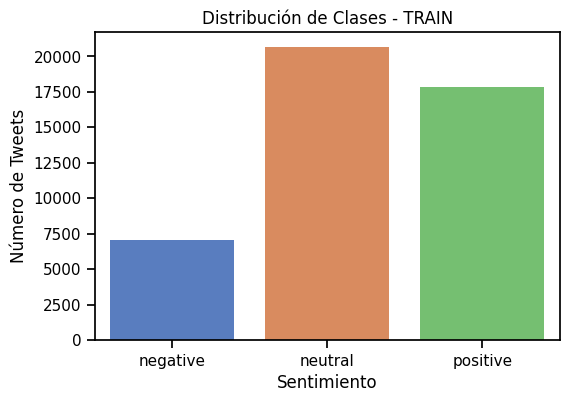

C:\Users\usuario\AppData\Local\Temp\ipykernel_9060\3923675950.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


DISTRIBUCIÓN DE CLASES - VALIDATION
            count  percentage
label_name                   
negative      312       15.60
neutral       869       43.45
positive      819       40.95

Resumen:
- negative: 312.0 ejemplos (15.6%)
- neutral: 869.0 ejemplos (43.45%)
- positive: 819.0 ejemplos (40.95%)




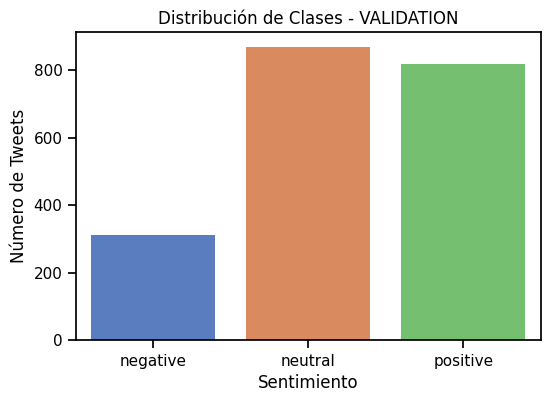

DISTRIBUCIÓN DE CLASES - TEST
            count  percentage
label_name                   
negative     3972       32.33
neutral      5937       48.33
positive     2375       19.33

Resumen:
- negative: 3972.0 ejemplos (32.33%)
- neutral: 5937.0 ejemplos (48.33%)
- positive: 2375.0 ejemplos (19.33%)




C:\Users\usuario\AppData\Local\Temp\ipykernel_9060\3923675950.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


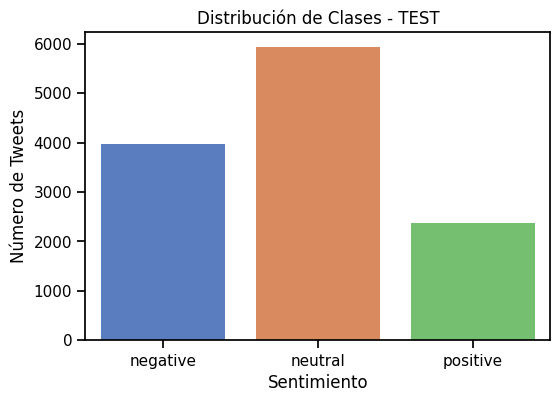

In [9]:
def show_class_distribution(df, split_name):
    counts = df["label_name"].value_counts().sort_index()
    percentages = (counts / counts.sum() * 100).round(2)
    distribution_df = pd.DataFrame({
        "count": counts,
        "percentage": percentages,
    })

    print("=" * 80)
    print(f"DISTRIBUCIÓN DE CLASES - {split_name.upper()}")
    print("=" * 80)
    print(distribution_df)

    print("\nResumen:")
    for label, row in distribution_df.iterrows():
        print(
            f"- {label}: "
            f"{row['count']} ejemplos "
            f"({row['percentage']}%)"
        )
    print("\n")
    
    plt.figure(figsize=(6, 4))
    sns.countplot(
        data=df, x="label_name", order=["negative", "neutral", "positive"], palette="muted"
    )
    plt.title(f"Distribución de Clases - {split_name.upper()}")
    plt.xlabel("Sentimiento")
    plt.ylabel("Número de Tweets")
    plt.show()

show_class_distribution(train_df, "Train")
show_class_distribution(val_df, "Validation")
show_class_distribution(test_df, "Test")

---

# 12. Longitud de los textos

En redes sociales la longitud de los textos es muy importante: afecta a la tokenización, al padding, al vocabulario y al coste de los modelos tipo Transformer.

In [10]:
# 1. Calculamos la longitud en palabras para el conjunto de Train
train_df['word_length'] = train_df['text'].apply(lambda x: len(str(x).split()))

print("Estadísticas descriptivas de la longitud de los textos en Train:")
print(train_df[['char_length', 'word_length']].describe().round(2))

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=train_df, 
    x='label_name', 
    y='word_length', 
    palette="muted",
    order=["negative", "neutral", "positive"]
)

plt.title('Distribución de longitud (palabras) por Sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Número de palabras')
plt.show()

Estadísticas descriptivas de la longitud de los textos en Train:


KeyError: "['char_length'] not in index"

---

# 13. Ruido típico de redes sociales

Creamos variables sencillas para medir la presencia de URLs, menciones, hashtags, caracteres no ASCII, mayúsculas y signos expresivos.

In [ ]:

def count_urls(text):
    return len(re.findall(r'https?://\S+|www\.\S+', str(text)))

def count_mentions(text):
    return len(re.findall(r'@\w+', str(text)))

def count_hashtags(text):
    return len(re.findall(r'#\w+', str(text)))

def count_emojis_or_non_ascii(text):
    return len(re.findall(r'[^\x00-\x7F]', str(text)))

def count_expressive_signs(text):
    return len(re.findall(r'[!?]', str(text)))

def count_all_caps_words(text):
    words = str(text).split()
    caps = [w for w in words if w.isupper() and len(w) > 1]
    return len(caps)

train_df['num_urls'] = train_df['text'].apply(count_urls)
train_df['num_mentions'] = train_df['text'].apply(count_mentions)
train_df['num_hashtags'] = train_df['text'].apply(count_hashtags)
train_df['num_non_ascii'] = train_df['text'].apply(count_emojis_or_non_ascii)
train_df['num_expressive_signs'] = train_df['text'].apply(count_expressive_signs)
train_df['num_all_caps'] = train_df['text'].apply(count_all_caps_words)

# 3. Calculamos el porcentaje de tweets que contienen al menos uno de estos elementos
features = ['num_urls', 'num_mentions', 'num_hashtags', 'num_non_ascii', 'num_expressive_signs', 'num_all_caps']
noise_stats = []

for feat in features:
    # Contamos cuántos textos tienen un valor mayor a 0 en esta característica
    count_with_feature = (train_df[feat] > 0).sum()
    percentage = (count_with_feature / len(train_df)) * 100
    
    # Limpiamos el nombre para que quede bonito en la tabla
    clean_name = feat.replace('num_', '').replace('_', ' ').capitalize()
    
    noise_stats.append({
        'Característica': clean_name,
        'Textos afectados': count_with_feature,
        'Porcentaje (%)': round(percentage, 2)
    })
 
noise_df = pd.DataFrame(noise_stats).sort_values(by='Porcentaje (%)', ascending=False)
print("PRESENCIA DE RUIDO EN EL CONJUNTO DE ENTRENAMIENTO:")
print(noise_df.to_string(index=False))

PRESENCIA DE RUIDO EN EL CONJUNTO DE ENTRENAMIENTO:
  Característica  Textos afectados  Porcentaje (%)
        All caps             14631           32.07
Expressive signs             13732           30.10
        Mentions             13429           29.44
        Hashtags              8526           18.69
            Urls                92            0.20
       Non ascii                 0            0.00


---

# 14. Ejemplos reales por clase

Antes de limpiar o modelar, conviene leer ejemplos reales. Esto ayuda a detectar ironía, ruido, etiquetas discutibles y clases difíciles.

In [ ]:
n_examples = 25


for label in ["negative", "neutral", "positive"]:
    print(f"\n[{label.upper()}]")
    
    sample_tweets = train_df[train_df['label_name'] == label]['text'].sample(n_examples)
    
    for i, text in enumerate(sample_tweets, 1):
        print(f"{i}. {text}")



[NEGATIVE]
1. "Frank Gifford always lived in someone's shadow, whether it was Howard Cosell's on ""Monday Night Football"" or Kathie Lee's in married life."
2. ok but louis hasnt been seen with briana since like what march ???? he is never with her and he looks so uncomfortable when interviewers+
3. Gutted #MUFC have fell out with Real Madrid. No chance we'll sign Bale and Ramos in January now.
4. @user @user @user im terrified of needles and HIV and sex can give HIV and condoms may protect from it
5. @user @user @user Most number of Muslims in the world R killed by fellow Muslims!1st sort it out&amp; then bark against Hindus
6. @user Just read Timmonsville is beating the crap out of McBee 60-8 still in the 3rd!!!
7. Daylight savings time ends this weekend. And I don't know what this means for the timing on F1 on Sunday.
8. @user @user I certainly wouldn\u2019t be spending my hard earnt  taking the kids to see say Shels 2nd XI v us\u002c clubs will fold no doubt
9. Because after a whi

---

# 15. Funciones iniciales de limpieza

Esta celda no pretende resolver toda la práctica. Es un punto de partida para que podáis comparar diferentes versiones del texto:

- `text_minimal`: limpieza mínima,
- `text_moderate`: limpieza razonable para redes sociales,
- `text_aggressive`: limpieza agresiva que puede ayudar o destruir señal.

La parte importante será comprobar experimentalmente qué versión funciona mejor y por qué.

In [ ]:
!pip install beautifulsoup4 contractions


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
def clean_minimal(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    return text

In [15]:
import re
import string
import contractions
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # <--- ¡La que yo te quité!
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


lemmatizer = WordNetLemmatizer()

#We remove the negation words from the stop words list
stop_words = set(stopwords.words('english'))
negations = {'not', 'no', 'nor', 'against', 'none', 'neither', 'isn', 'aren', 'wasn', 'weren', 'haven', 'hasn', 'hadn', 'won', 'wouldn', 'don', 'doesn', 'didn', 'can', 'couldn', 'shouldn', 'mightn', 'mustn'}
safe_stop_words = stop_words - negations


#Minimal cleaning
def clean_minimal(text):
    text = str(text)
    #We clean html tags
    text = BeautifulSoup(text, "html.parser").get_text()
    #We expand contractions, meaning that don't will become do not.
    text = contractions.fix(text)
    #We eliminate weird spaces such as line skips or extra space
    text = re.sub(r'\s+', ' ', text).strip()
    return text


#Moderate cleaning
def clean_moderate(text):
    #Same as the minimal, adding the .lower
    text = str(text).lower()
    text = BeautifulSoup(text, "html.parser").get_text()
    text = contractions.fix(text)
    
    #We replace specific links and mentions with the placeholders <URL> and <USER>.
    text = re.sub(r'http\S+|www\S+', '<URL>', text)
    text = re.sub(r'@\w+', '<USER>', text)
    #Same as the minimal
    text = re.sub(r'\s+', ' ', text).strip()
    return text


#Agressive cleaning
def clean_aggressive(text):
    #Same as the previous two
    text = str(text).lower()
    text = BeautifulSoup(text, "html.parser").get_text()
    text = contractions.fix(text)
    
    #We remove links, tags and numbers
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\d+', '', text)
    
    #We remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    #We tokenize the text
    tokens = word_tokenize(text)
    
    #We lemmatize (turns words into their "root" word, better will become good, was will become be...) the tokens and remove the stop words with the negation filter we applied earlier.
    cleaned_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in safe_stop_words
    ]
    
    #We join the cleaned words back into a single string to return.
    return " ".join(cleaned_tokens)

---

# 16. Variables listas para modelar

Recomendación inicial: empezar con `text_moderate` y comparar después contra `text_minimal`, `text_aggressive` y `text` original.

In [18]:
print("Applying")
#Apply cleaning to the train set
train_df['text_minimal'] = train_df['text'].apply(clean_minimal)
train_df['text_moderate'] = train_df['text'].apply(clean_moderate)
train_df['text_aggressive'] = train_df['text'].apply(clean_aggressive)

#Apply cleaning to the validation set
val_df['text_minimal'] = val_df['text'].apply(clean_minimal)
val_df['text_moderate'] = val_df['text'].apply(clean_moderate)
val_df['text_aggressive'] = val_df['text'].apply(clean_aggressive)

#Apply cleaning to the test set
test_df['text_minimal'] = test_df['text'].apply(clean_minimal)
test_df['text_moderate'] = test_df['text'].apply(clean_moderate)
test_df['text_aggressive'] = test_df['text'].apply(clean_aggressive)

print("Apllied successfully")
#We print the first 10 examples of the original and cleaned text to see the differences
train_df[['text', 'text_minimal', 'text_moderate', 'text_aggressive']].head(10)

Applying
Apllied successfully


,text,text_minimal,text_moderate,text_aggressive
0,"""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""","""QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin""","""qt <USER> in the original draft of the 7th book, remus lupin survived the battle of hogwarts. #happybirthdayremuslupin""",qt original draft th book remus lupin survived battle hogwarts happybirthdayremuslupin
1,"""Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ""","""Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ""","""ben smith / smith (concussion) remains out of the lineup thursday, curtis #nhl #sj""",ben smith smith concussion remains lineup thursday curtis nhl sj
2,Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.,Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.,sorry bout the stream last night i crashed out but will be on tonight for sure. then back to minecraft in pc tomorrow night.,sorry bout stream last night crashed tonight sure back minecraft pc tomorrow night
3,Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays,Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays,chase headley's rbi double in the 8th inning off david price snapped a yankees streak of 33 consecutive scoreless innings against blue jays,chase headleys rbi double th inning david price snapped yankee streak consecutive scoreless inning against blue jay
4,"@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017""","@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017""","<USER> alciato: bee will invest 150 million in january, another 200 in the summer and plans to bring messi by 2017""",alciato bee invest million january another summer plan bring messi
5,@user LIT MY MUM 'Kerry the louboutins I wonder how many Willam owns!!! Look Kerry Warner Wednesday!',@user LIT MY MUM 'Kerry the louboutins I wonder how many Willam owns!!! Look Kerry Warner Wednesday!',<USER> lit my mum 'kerry the louboutins i wonder how many willam owns!!! look kerry warner wednesday!',lit mum kerry louboutins wonder many willam owns look kerry warner wednesday
6,"""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIAL ft T.dot FINEST rocking the mic...CRAZY CACTUS NIGHT CLUB ..ADV ticket $10 wt out costume $15...""","""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIAL ft T.dot FINEST rocking the mic...CRAZY CACTUS NIGHT CLUB ..ADV ticket $10 wt out costume $15...""","""\"""""""" soul train\"""""""" oct 27 halloween special ft t.dot finest rocking the mic...crazy cactus night club ..adv ticket $10 wt out costume $15...""",soul train oct halloween special ft tdot finest rocking miccrazy cactus night club adv ticket wt costume
7,So disappointed in wwe summerslam! I want to see john cena wins his 16th title,So disappointed in wwe summerslam! I want to see john cena wins his 16th title,so disappointed in wwe summerslam! i want to see john cena wins his 16th title,disappointed wwe summerslam want see john cena win th title
8,"""This is the last Sunday w/o football .....,NFL is back baby""","""This is the last Sunday w/o football .....,NFL is back baby""","""this is the last sunday w/o football .....,nfl is back baby""",last sunday wo football nfl back baby
9,@user @user CENA & AJ sitting in a tree K-I-S-S-I-N-G 1st goes AJ's job then John's cred then goes Vicki with the GM position.,@user @user CENA & AJ sitting in a tree K-I-S-S-I-N-G 1st goes AJ's job then John's cred then goes V

---

# 17. Función común de evaluación

Esta función permite evaluar cualquier modelo que devuelva predicciones de clase. Usad las mismas métricas para comparar modelos clásicos, redes neuronales, modelos preentrenados y LLMs.

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    precision_recall_fscore_support
)

def evaluate_model(y_true, y_pred, model_name="Modelo"):
    #We calculate precision, recall and f1-score for each class and print the classification report
    target_names = ['negative', 'neutral', 'positive']
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
    
    #We extract the Accuracy and the Macro-F1 to return them and use them in our final table
    acc = accuracy_score(y_true, y_pred)
    _, _, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    
    #We create the confusion matrix and display it
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    
    #We plot the confusion matrix     
    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f'Matriz de Confusión: {model_name}')
    plt.show()
    
    return acc, macro_f1

---

# 18. Baseline mínimo de comprobación

Esta celda solo comprueba que los datos están listos y que el pipeline funciona. No sustituye a la batería completa de experimentos que debéis realizar.

Training baseline
              precision    recall  f1-score   support

    negative       0.61      0.40      0.48       312
     neutral       0.63      0.76      0.69       869
    positive       0.75      0.68      0.72       819

    accuracy                           0.67      2000
   macro avg       0.66      0.62      0.63      2000
weighted avg       0.68      0.67      0.67      2000



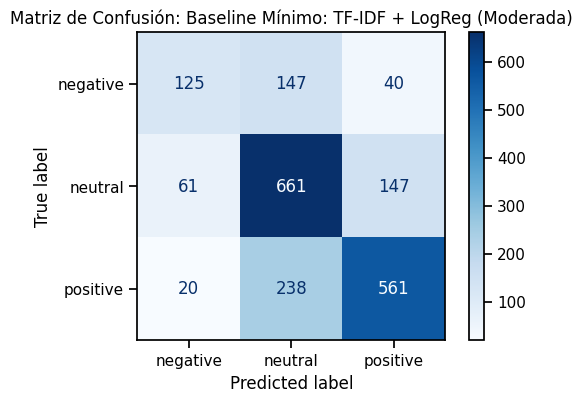

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("Training baseline")

#We create a pipeline that combines text vectorization and the mathematical model
baseline_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=50))
])

#We start with the moderate as recommended in the instructions
baseline_pipeline.fit(train_df['text_moderate'], train_df['label'])

#We make the model try to guess the sentiment on the validation set    
y_pred_baseline = baseline_pipeline.predict(val_df['text_moderate'])

#We evaluate the model using the function we created before
acc_base, f1_base = evaluate_model(
    y_true=val_df['label'], 
    y_pred=y_pred_baseline, 
    model_name="Baseline Mínimo: TF-IDF + LogReg (Moderada)"
)

---

# 19. Tabla de resultados

Conviene guardar todos los experimentos en una tabla final con columnas como:

- nombre del experimento,
- limpieza usada,
- representación,
- modelo,
- métricas,
- comentario interpretativo.

---

# 20. Si queréis usar otro dataset

Podéis sustituir el dataset por otro siempre que mantengáis una estructura equivalente.

Idealmente deberíais acabar teniendo tres DataFrames:

- `train_df`
- `val_df`
- `test_df`

Y cada uno debería tener, como mínimo:

- `text`
- `label`
- `label_name`

Si el dataset solo viene con train/test, podéis crear validación desde train usando `train_test_split`. Si las etiquetas vienen como texto, convertidlas a IDs numéricos.

In [ ]:
# Plantilla orientativa si usáis un CSV propio.
# No ejecutéis esta celda salvo que tengáis el archivo preparado.

# custom_df = pd.read_csv("ruta/a/mi_dataset.csv")
# custom_df = custom_df.rename(columns={
#     "nombre_columna_texto": "text",
#     "nombre_columna_etiqueta": "label_name",
# })
# label_to_id = {label: idx for idx, label in enumerate(sorted(custom_df["label_name"].unique()))}
# id_to_label = {v: k for k, v in label_to_id.items()}
# custom_df["label"] = custom_df["label_name"].map(label_to_id)
#
# train_df, temp_df = train_test_split(
#     custom_df,
#     test_size=0.30,
#     random_state=SEED,
#     stratify=custom_df["label"],
# )
# val_df, test_df = train_test_split(
#     temp_df,
#     test_size=0.50,
#     random_state=SEED,
#     stratify=temp_df["label"],
# )

---

# 21. Secciones que debéis desarrollar

A partir de aquí empieza vuestro trabajo.

## 21.1. Análisis exploratorio

Profundizad en distribución de clases, ejemplos por clase, longitud de textos, hashtags, menciones, URLs, emojis, tokens frecuentes, duplicados y posibles problemas de etiquetado.

## 21.2. Limpieza y preprocesamiento

Comparad al menos dos versiones de limpieza. No asumáis que limpiar más siempre mejora.

## 21.3. Modelos clásicos

Probad varias configuraciones: CountVectorizer, TF-IDF, unigramas, bigramas, Regresión logística, Naive Bayes y Linear SVM.

## 21.4. Red neuronal

Implementad al menos una arquitectura neuronal: LSTM, GRU, CNN 1D o Transformer block con Keras.

## 21.5. Modelo avanzado o LLM

Podéis hacer fine-tuning de DistilBERT/BERT/RoBERTa/MiniLM o evaluación zero-shot/few-shot con un LLM.

## 21.6. Comparación final y conclusiones

Incluid tabla comparativa, métricas comunes, matrices de confusión, análisis de errores y discusión crítica.

La conclusión debe responder:

> ¿Qué modelo recomendaríais para este problema concreto y bajo qué condiciones?

In [ ]:
experiment_template = pd.DataFrame([
    {
        "experiment": "ejemplo_1",
        "text_column": "text_moderate",
        "representation": "TF-IDF",
        "model": "Linear SVM",
        "accuracy": np.nan,
        "macro_precision": np.nan,
        "macro_recall": np.nan,
        "macro_f1": np.nan,
        "comment": "Sustituir por interpretación del resultado.",
    },
    {
        "experiment": "ejemplo_2",
        "text_column": "text_moderate",
        "representation": "Embedding entrenado desde cero",
        "model": "LSTM / GRU / Transformer Keras",
        "accuracy": np.nan,
        "macro_precision": np.nan,
        "macro_recall": np.nan,
        "macro_f1": np.nan,
        "comment": "Sustituir por interpretación del resultado.",
    },
    {
        "experiment": "ejemplo_3",
        "text_column": "text original",
        "representation": "Tokenizer preentrenado o prompt",
        "model": "DistilBERT / RoBERTa / LLM",
        "accuracy": np.nan,
        "macro_precision": np.nan,
        "macro_recall": np.nan,
        "macro_f1": np.nan,
        "comment": "Sustituir por interpretación del resultado.",
    },
])

experiment_template

,experiment,text_column,representation,model,accuracy,macro_precision,macro_recall,macro_f1,comment
0,ejemplo_1,text_moderate,TF-IDF,Linear SVM,NaN,NaN,NaN,NaN,Sustituir por interpretación del resultado.
1,ejemplo_2,text_moderate,Embedding entrenado desde cero,LSTM / GRU / Transformer Keras,NaN,NaN,NaN,NaN,Sustituir por interpretación del resultado.
2,ejemplo_3,text original,Tokenizer preentrenado o prompt,DistilBERT / RoBERTa / LLM,NaN,NaN,NaN,NaN,Sustituir por interpretación del resultado.


---

# 22. Recordatorio final

Esta práctica no consiste en buscar únicamente el número más alto.

Un buen trabajo debe demostrar que entendéis:

- cómo son los datos,
- cómo afecta la limpieza,
- qué aprende cada tipo de modelo,
- qué coste tiene cada enfoque,
- qué errores comete,
- cuándo merece la pena usar un modelo más complejo,
- cuándo un modelo clásico bien trabajado puede ser suficiente.

El resultado final debe ser una comparación razonada, no una colección de modelos entrenados sin análisis.